# SKALA DS MINI PROJECT

충방전 특성을 활용한 배터리 수명 그룹 조기 분류

## 1. 라이브러리 준비

In [ ]:
from pathlib import Path

import mat73
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import re

from IPython.display import display

## 2. 데이터 경로

In [30]:
# 저장소 루트 또는 code 폴더에서 실행할 수 있도록 프로젝트 경로를 찾습니다.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "code/pipeline.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("DS-Miniproject 폴더에서 노트북을 실행하세요.")
DATA_DIR = ROOT / "data/rawdata/archive"
files = sorted(DATA_DIR.glob("*.mat"))
print(f"파일 개수: {len(files)}")
for i, file in enumerate(files):
    print(f"[{i}] {file.name} ({file.stat().st_size / 1024 ** 3:.2f} GB)")


파일 개수: 4

[0] 2017-05-12_batchdata_updated_struct_errorcorrect.mat (2.82 GB)
[1] 2018-02-20_batchdata_updated_struct_errorcorrect.mat (1.88 GB)
[2] 2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat (0.08 GB)
[3] 2018-04-12_batchdata_updated_struct_errorcorrect.mat (3.01 GB)


In [31]:
dataset_paths = {
    "batch1": DATA_DIR / "2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    "batch2": DATA_DIR / "2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "batch3": DATA_DIR / "2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}
for path in dataset_paths.values():
    if not path.is_file():
        raise FileNotFoundError(f"원본 데이터가 없습니다: {path}. README의 데이터 준비를 확인하세요.")


## 3. 로딩 함수
세 파일은 MATLAB v7.3 형식이므로 `mat73`로 읽는다.
`batch`를 배터리별 딕셔너리의 리스트로 정리한다.

In [32]:
def load_batch(path):
    mat = mat73.loadmat(str(path))
    print("로딩 방식: mat73 / MATLAB v7.3 (HDF5)")
    print("로드 결과 타입:", type(mat))
    print("최상위 key:", list(mat.keys()))

    batch = mat["batch"]
    print("원래 batch 타입:", type(batch))
    if isinstance(batch, dict):
        keys = list(batch.keys())
        n_cells = len(batch[keys[0]])
        batch = [{key: batch[key][i] for key in keys} for i in range(n_cells)]

    print("배터리 셀 수:", len(batch))
    print("정리한 batch 타입:", type(batch))
    print("첫 번째 셀 key:", list(batch[0].keys()))
    return batch

## 4. Batch별로 로딩

In [33]:
batch1 = load_batch(dataset_paths["batch1"])

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 방식: mat73 / MATLAB v7.3 (HDF5)
로드 결과 타입: <class 'dict'>
최상위 key: ['batch', 'batch_date']
원래 batch 타입: <class 'dict'>
배터리 셀 수: 46
정리한 batch 타입: <class 'list'>
첫 번째 셀 key: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [34]:
batch2 = load_batch(dataset_paths["batch2"])

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 방식: mat73 / MATLAB v7.3 (HDF5)
로드 결과 타입: <class 'dict'>
최상위 key: ['batch', 'batch_date']
원래 batch 타입: <class 'dict'>
배터리 셀 수: 47
정리한 batch 타입: <class 'list'>
첫 번째 셀 key: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [35]:
batch3 = load_batch(dataset_paths["batch3"])

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 방식: mat73 / MATLAB v7.3 (HDF5)
로드 결과 타입: <class 'dict'>
최상위 key: ['batch', 'batch_date']
원래 batch 타입: <class 'dict'>
배터리 셀 수: 46
정리한 batch 타입: <class 'list'>
첫 번째 셀 key: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


## 5. 배터리 구조 확인

In [36]:
def show_structure(data):
    for key, value in data.items():
        if isinstance(value, np.ndarray):
            print(f"{key}: ndarray, shape={value.shape}, dtype={value.dtype}")
        elif isinstance(value, dict):
            print(f"{key}: dict, keys={list(value.keys())}")
        elif isinstance(value, list):
            print(f"{key}: list, length={len(value)}")
        else:
            print(f"{key}: {type(value).__name__}, value={value}")

In [37]:
batches = {"batch1": batch1, "batch2": batch2, "batch3": batch3}

for name, batch in batches.items():
    print(f"\n[{name} 첫 번째 배터리]")
    show_structure(batch[0])


[batch1 첫 번째 배터리]
Vdlin: ndarray, shape=(1000,), dtype=float64
barcode: NoneType, value=None
channel_id: NoneType, value=None
cycle_life: ndarray, shape=(), dtype=float64
cycles: dict, keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
policy: str, value=3_6C-80PER_3_6C
policy_readable: str, value=3.6C(80%)-3.6C
summary: dict, keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']

[batch2 첫 번째 배터리]
Vdlin: ndarray, shape=(1000,), dtype=float64
barcode: NoneType, value=None
channel_id: NoneType, value=None
cycle_life: ndarray, shape=(), dtype=float64
cycles: dict, keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
policy: str, value=5_2C_58PER_4C
policy_readable: str, value=5.2C(58%)-4C
summary: dict, keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']

[batch3 첫 번째 배터리]
Vdlin: ndarray, shape=(1000,), dtype=float64
barcode: NoneType, value=None
channel_id: NoneType, value=None
cyc

### summary 내부 확인

In [38]:
for name, batch in batches.items():
    print(f"\n[{name} summary]")
    show_structure(batch[0]["summary"])


[batch1 summary]
IR: ndarray, shape=(1189,), dtype=float64
QCharge: ndarray, shape=(1189,), dtype=float64
QDischarge: ndarray, shape=(1189,), dtype=float64
Tavg: ndarray, shape=(1189,), dtype=float64
Tmax: ndarray, shape=(1189,), dtype=float64
Tmin: ndarray, shape=(1189,), dtype=float64
chargetime: ndarray, shape=(1189,), dtype=float64
cycle: ndarray, shape=(1189,), dtype=float64

[batch2 summary]
IR: ndarray, shape=(496,), dtype=float64
QCharge: ndarray, shape=(496,), dtype=float64
QDischarge: ndarray, shape=(496,), dtype=float64
Tavg: ndarray, shape=(496,), dtype=float64
Tmax: ndarray, shape=(496,), dtype=float64
Tmin: ndarray, shape=(496,), dtype=float64
chargetime: ndarray, shape=(496,), dtype=float64
cycle: ndarray, shape=(496,), dtype=float64

[batch3 summary]
IR: ndarray, shape=(1008,), dtype=float64
QCharge: ndarray, shape=(1008,), dtype=float64
QDischarge: ndarray, shape=(1008,), dtype=float64
Tavg: ndarray, shape=(1008,), dtype=float64
Tmax: ndarray, shape=(1008,), dtype=flo

### cycles 내부 확인
첫 번째 사이클이 비어 있을 수 있어 두 번째 사이클도 확인한다.

In [39]:
for name, batch in batches.items():
    cycles = batch[0]["cycles"]
    if isinstance(cycles, dict):
        keys = list(cycles.keys())
        cycles = [
            {key: cycles[key][i] for key in keys}
            for i in range(len(cycles[keys[0]]))
        ]

    print(f"\n[{name}] 사이클 수: {len(cycles)}")
    for i, cycle in enumerate(cycles[:2]):
        print(f"  cycles[{i}]")
        show_structure(cycle)


[batch1] 사이클 수: 1189
  cycles[0]
I: NoneType, value=None
Qc: NoneType, value=None
Qd: NoneType, value=None
Qdlin: NoneType, value=None
T: NoneType, value=None
Tdlin: NoneType, value=None
V: NoneType, value=None
discharge_dQdV: NoneType, value=None
t: NoneType, value=None
  cycles[1]
I: ndarray, shape=(1087,), dtype=float64
Qc: ndarray, shape=(1087,), dtype=float64
Qd: ndarray, shape=(1087,), dtype=float64
Qdlin: ndarray, shape=(1000,), dtype=float64
T: ndarray, shape=(1087,), dtype=float64
Tdlin: ndarray, shape=(1000,), dtype=float64
V: ndarray, shape=(1087,), dtype=float64
discharge_dQdV: ndarray, shape=(1000,), dtype=float64
t: ndarray, shape=(1087,), dtype=float64

[batch2] 사이클 수: 496
  cycles[0]
I: ndarray, shape=(1042,), dtype=float64
Qc: ndarray, shape=(1042,), dtype=float64
Qd: ndarray, shape=(1042,), dtype=float64
Qdlin: ndarray, shape=(1000,), dtype=float64
T: ndarray, shape=(1042,), dtype=float64
Tdlin: ndarray, shape=(1000,), dtype=float64
V: ndarray, shape=(1042,), dtype=f

### Batch별 key 비교

In [40]:
for name, batch in batches.items():
    cell = batch[0]
    cycles = cell["cycles"]
    cycle_keys = list(cycles.keys()) if isinstance(cycles, dict) else list(cycles[0].keys())
    print(f"\n{name}: {len(batch)}개 배터리")
    print("batch key:", list(cell.keys()))
    print("summary key:", list(cell["summary"].keys()))
    print("cycles key:", cycle_keys)


batch1: 46개 배터리
batch key: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
summary key: ['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']
cycles key: ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']

batch2: 47개 배터리
batch key: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
summary key: ['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']
cycles key: ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']

batch3: 46개 배터리
batch key: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
summary key: ['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']
cycles key: ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']


## 6. 데이터 추출
cells: 배터리별 수명, 충전 정책, 초기 피처 -> 사이클 10.100의 Qdlin  
summary: 사이클별 용량, 온도, 저항  
delta: 전압별 ΔQ(V)

In [44]:
def make_batch_tables(batch, batch_name):
    cell_rows = []
    summary_frames = []
    delta_frames = []

    for i, cell in enumerate(batch):
        cell_id = f"{batch_name}_cell{i}"

        # 1. 사이클별 summary
        summary = pd.DataFrame({
            key: np.asarray(value).reshape(-1)
            for key, value in cell["summary"].items()
        })

        summary["batch"] = batch_name
        summary["cell_id"] = cell_id
        summary_frames.append(summary)

        # 2. 배터리 기본 정보
        life = float(np.asarray(cell["cycle_life"]).reshape(-1)[0])
        policy = str(cell["policy_readable"])

        # 예: "3.6C(80%)-3.6C"에서 첫 충전 C-rate 추출
        match = re.search(r"([\d.]+)C", policy)
        c_rate = float(match.group(1)) if match else np.nan

        # 초기 사이클 10~100의 특징
        early = summary[
            summary["cycle"].between(10, 100)
        ].copy()

        # 용량 그래프/기울기에서 사용할 탐색적 유효 범위
        valid = summary[
            summary["QDischarge"].between(0, 1.43, inclusive="neither")
        ]
        early_valid = valid[valid["cycle"].between(10, 100)]

        row = {
            "batch": batch_name,
            "cell_id": cell_id,
            "cycle_life": life,
            "policy": policy,
            "C_rate": c_rate,
            "early_cycles": early["cycle"].nunique(),
            "early_QD": early_valid["QDischarge"].mean(),
            "early_IR": early["IR"].mean(),
            "early_Tmax": early["Tmax"].mean(),
            "early_chargetime": early["chargetime"].mean(),
            "early_QD_slope": np.nan,
            "full_QD_slope": np.nan,
            "delta_logvar": np.nan,
            "delta_min": np.nan,
        }

        if len(early_valid) >= 3:
            row["early_QD_slope"] = np.polyfit(
                early_valid["cycle"],
                early_valid["QDischarge"],
                1,
            )[0]

        if len(valid) >= 3:
            row["full_QD_slope"] = np.polyfit(
                valid["cycle"],
                valid["QDischarge"],
                1,
            )[0]

        # 3. cycles를 사이클별 리스트로 정리
        cycles = cell["cycles"]

        if isinstance(cycles, dict):
            keys = list(cycles)
            cycles = [
                {key: cycles[key][j] for key in keys}
                for j in range(len(cycles[keys[0]]))
            ]

        # summary의 실제 사이클 번호와 cycles 위치 연결
        if len(cycles) != len(summary):
            raise ValueError(f"{cell_id}: summary와 cycles 길이 확인 필요")

        cycle_map = dict(zip(summary["cycle"], cycles))

        # 4. ΔQ(V) = Q100(V) - Q10(V)
        if 10 in cycle_map and 100 in cycle_map:
            q10 = cycle_map[10].get("Qdlin")
            q100 = cycle_map[100].get("Qdlin")

            if q10 is not None and q100 is not None:
                voltage = np.asarray(cell["Vdlin"]).reshape(-1)
                q10 = np.asarray(q10, dtype=float).reshape(-1)
                q100 = np.asarray(q100, dtype=float).reshape(-1)

                if len(voltage) == len(q10) == len(q100) > 1:
                    delta = pd.DataFrame({
                        "voltage": voltage,
                        "delta_Q": q100 - q10,
                    }).replace([np.inf, -np.inf], np.nan).dropna()

                    if len(delta) > 1:
                        delta["batch"] = batch_name
                        delta["cell_id"] = cell_id
                        delta_frames.append(delta)

                        row["delta_logvar"] = np.log10(
                            max(delta["delta_Q"].var(ddof=0), 1e-12)
                        )
                        row["delta_min"] = delta["delta_Q"].min()

        cell_rows.append(row)

    return {
        "cells": pd.DataFrame(cell_rows),
        "summary": pd.concat(summary_frames, ignore_index=True),
        "delta": pd.concat(delta_frames, ignore_index=True)
        if delta_frames else pd.DataFrame(
            columns=["voltage", "delta_Q", "batch", "cell_id"]
        ),
    }

In [ ]:
tables = {}

for name, batch in batches.items():
    tables[name] = make_batch_tables(batch, name)

df_cells = pd.concat(
    [table["cells"] for table in tables.values()],
    ignore_index=True,
)

df_summary = pd.concat(
    [table["summary"] for table in tables.values()],
    ignore_index=True,
)

df_delta = pd.concat(
    [table["delta"] for table in tables.values()],
    ignore_index=True,
)

df_cells["life_group"] = np.select(
    [
        df_cells["cycle_life"].isna(),
        df_cells["cycle_life"] < 500,
        df_cells["cycle_life"] > 1000,
    ],
    ["unknown", "short", "long"],
    default="middle",
)

display(df_cells.head())
display(df_summary.head())
display(df_delta.head())

## 7. EDA

### 1) Cycle Life 분포

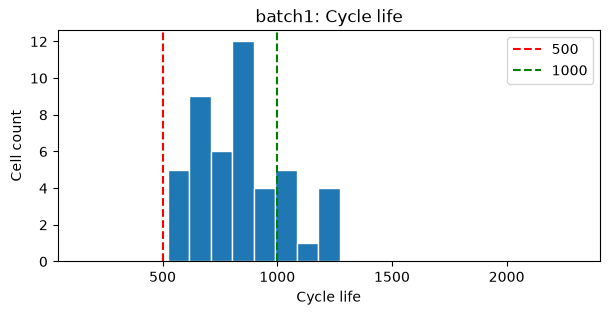

batch1: 단수(<500) 0.0%, 장수(>1000) 21.7%


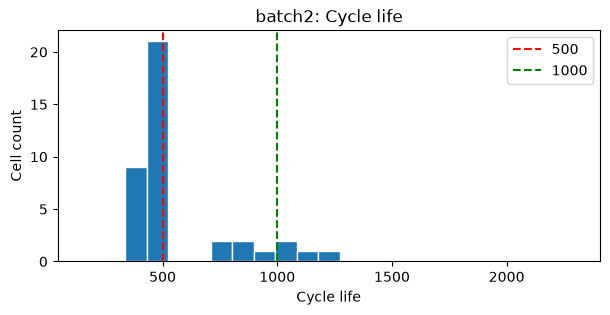

batch2: 단수(<500) 71.8%, 장수(>1000) 7.7%


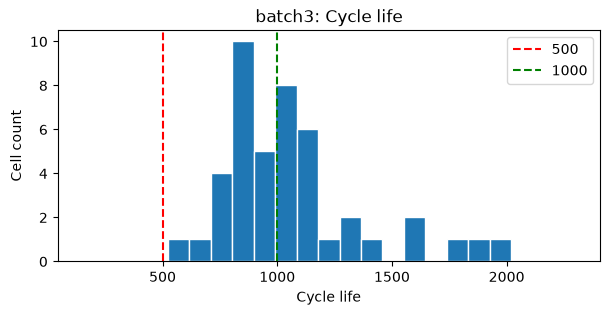

batch3: 단수(<500) 0.0%, 장수(>1000) 52.3%


,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
batch1,46.0,844.7,184.6,534.0,703.2,858.5,914.2,1227.0
batch2,39.0,565.7,222.2,392.0,439.5,472.0,508.5,1186.0
batch3,44.0,1059.7,313.9,541.0,828.0,1005.5,1155.2,1935.0


,batch,cell_id,cycle_life,policy


수명 결측 셀


,batch,cell_id,policy
68,batch2,batch2_cell22,VarCharge-2C-100cycles
69,batch2,batch2_cell23,VarCharge-4C-100cycles
81,batch2,batch2_cell35,VarCharge-6C-100cycles
82,batch2,batch2_cell36,VarCharge-8C-100cycles
83,batch2,batch2_cell37,3.6C(80%)-3.6C(SLOWCYCLE
84,batch2,batch2_cell38,4.8C(80%)-4.8C(SLOWCYCLE
85,batch2,batch2_cell39,3.6C(9%)-5C(SLOWCYCLE
86,batch2,batch2_cell40,5.2C(58%)-4C(SLOWCYCLE
116,batch3,batch3_cell23,4.8C(80%)-4.8C-newstructure
125,batch3,batch3_cell32,4.8C(80%)-4.8C-newstructure


In [54]:
for name, data in df_cells.groupby("batch"):
    life = data["cycle_life"].dropna()

    plt.figure(figsize=(7, 3))
    plt.hist(life, bins=np.linspace(150, 2300, 24), edgecolor="white")
    plt.axvline(500, color="red", linestyle="--", label="500")
    plt.axvline(1000, color="green", linestyle="--", label="1000")
    plt.title(f"{name}: Cycle life")
    plt.xlabel("Cycle life")
    plt.ylabel("Cell count")
    plt.legend()
    plt.show()

    print(
        f"{name}: 단수(<500) {life.lt(500).mean():.1%}, "
        f"장수(>1000) {life.gt(1000).mean():.1%}"
    )

display(
    df_cells.groupby("batch")["cycle_life"].describe().round(1)
)

# 표시 범위 밖의 셀 확인
display(
    df_cells.loc[
        df_cells["cycle_life"].notna()
        & ~df_cells["cycle_life"].between(150, 2300),
        ["batch", "cell_id", "cycle_life", "policy"],
    ]
)
# 수명 결측치는 이상치와 구분하여 확인
print("수명 결측 셀")
display(df_cells.loc[df_cells["cycle_life"].isna(), ["batch", "cell_id", "policy"]])


### 2) 방전 용량 감소 추이

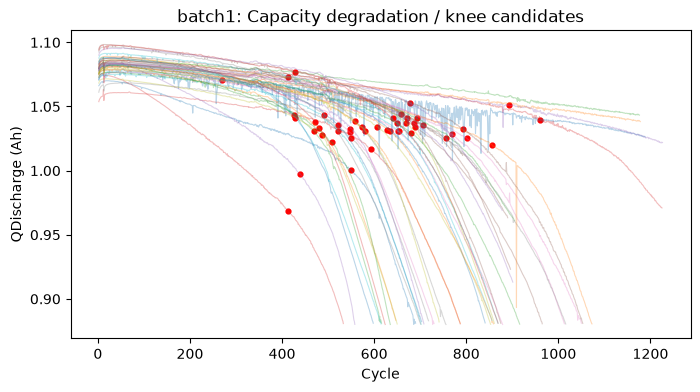

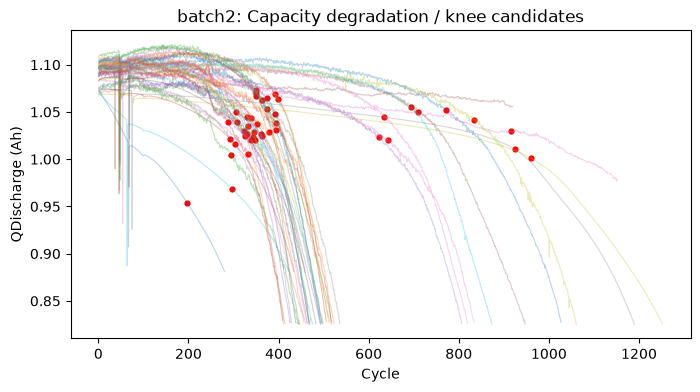

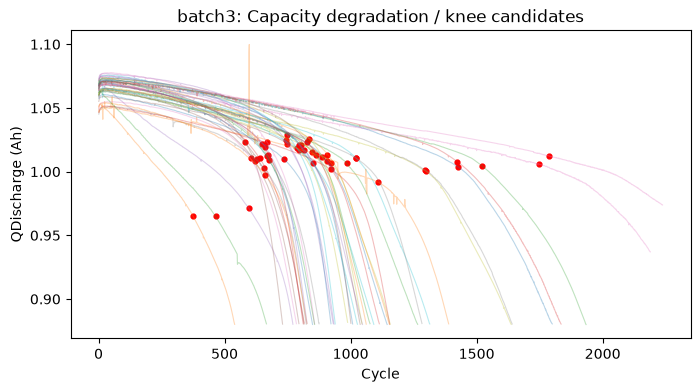

,count,median
batch,,
batch1,46,600.5
batch2,44,351.0
batch3,46,799.0


,early_QD_slope,full_QD_slope
batch,,
batch1,-0.000014,-0.000174
batch2,-0.000006,-0.000376
batch3,-0.000015,-0.000118


In [55]:
def find_knee(curve):
    x = curve["cycle"].to_numpy()
    y = curve["QDischarge"].rolling(
        15, center=True, min_periods=1
    ).median().to_numpy()

    if len(x) < 80 or np.unique(x).size < 3:
        return np.nan

    # 한 직선과 연속된 두 직선의 적합 비교
    single = np.polyval(np.polyfit(x, y, 1), x)
    single_error = np.sum((y - single) ** 2)

    candidates = []

    for j in range(int(len(x) * 0.2), int(len(x) * 0.8), 5):
        design = np.column_stack([
            np.ones(len(x)), x, np.maximum(0, x - x[j])
        ])
        coef = np.linalg.lstsq(design, y, rcond=None)[0]

        error = np.sum((y - design @ coef) ** 2)
        before = coef[1]
        after = coef[1] + coef[2]

        candidates.append((error, x[j], before, after))

    error, knee, before, after = min(candidates)

    improvement = 1 - error / max(single_error, 1e-12)

    if improvement > 0.2 and after < -1.5 * abs(before):
        return knee

    return np.nan


knee_rows = []

for name, data in df_summary.groupby("batch"):
    plt.figure(figsize=(8, 4))

    for cell_id, cell in data.groupby("cell_id"):
        curve = (
            cell.loc[
                cell["QDischarge"].between(
                    0, 1.43, inclusive="neither"
                ),
                ["cycle", "QDischarge"],
            ]
            .groupby("cycle", as_index=False).median()
            .sort_values("cycle")
        )

        plt.plot(
            curve["cycle"], curve["QDischarge"],
            alpha=0.3, linewidth=0.8,
        )

        knee = find_knee(curve)
        knee_rows.append({
            "batch": name, "cell_id": cell_id, "knee_cycle": knee
        })

        if np.isfinite(knee):
            capacity = np.interp(
                knee, curve["cycle"], curve["QDischarge"]
            )
            plt.scatter(knee, capacity, color="red", s=12)

    plt.title(f"{name}: Capacity degradation / knee candidates")
    plt.xlabel("Cycle")
    plt.ylabel("QDischarge (Ah)")
    plt.show()

df_knee = pd.DataFrame(knee_rows)

display(
    df_knee.groupby("batch")["knee_cycle"]
    .agg(["count", "median"])
)

display(
    df_cells.groupby("batch")[
        ["early_QD_slope", "full_QD_slope"]
    ].median()
)

### 3) 초기 사이클의 차이

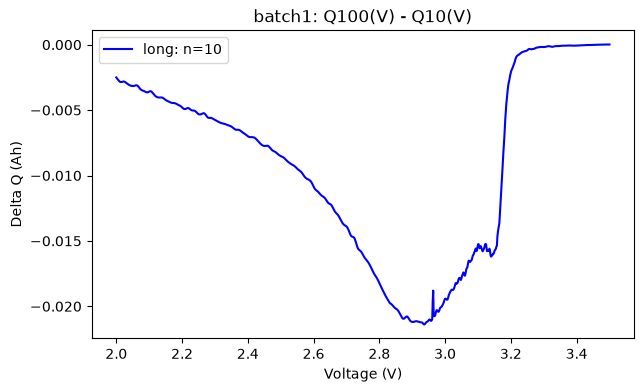

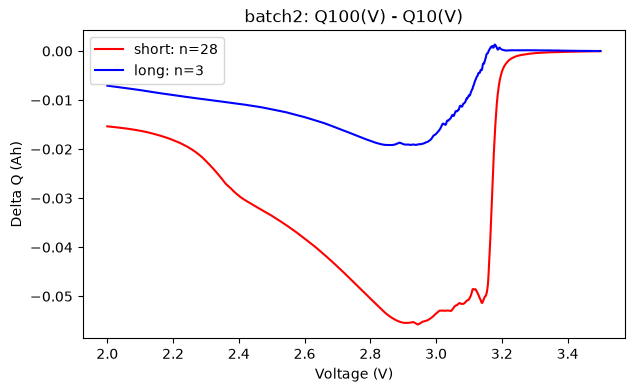

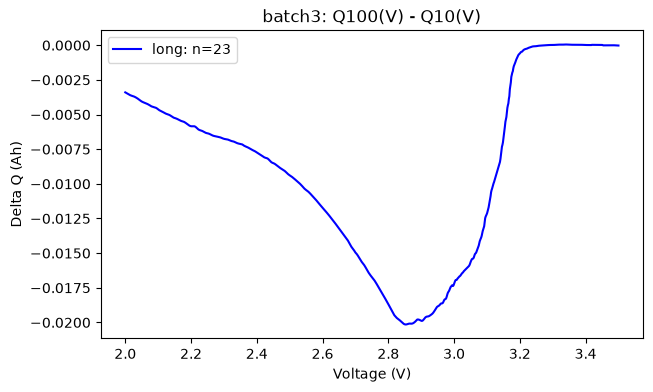

delta_logvar           delta_min          
                         count    median     count    median
batch  life_group                                           
batch1 long                 10 -4.310746        10 -0.022070
       middle               36 -3.786476        36 -0.038294
batch2 long                  3 -4.271782         3 -0.019165
       middle               16 -4.153341        16 -0.028261
       short                28 -3.446103        28 -0.056180
batch3 long                 23 -4.316748        23 -0.020147
       middle               23 -4.094466        23 -0.026849

In [56]:
delta_plot = df_delta.merge(
    df_cells[["cell_id", "life_group"]],
    on="cell_id",
    how="left",
)

for name, data in delta_plot.groupby("batch"):
    plt.figure(figsize=(7, 4))

    for group, color in [("short", "red"), ("long", "blue")]:
        selected = data[data["life_group"] == group]

        if selected.empty:
            continue

        curve = (
            selected.groupby("voltage")["delta_Q"]
            .median().sort_index()
        )

        plt.plot(
            curve.index, curve.values,
            color=color,
            label=f"{group}: n={selected['cell_id'].nunique()}",
        )

    plt.title(f"{name}: Q100(V) - Q10(V)")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Delta Q (Ah)")

    if plt.gca().get_legend_handles_labels()[0]:
        plt.legend()

    plt.show()

display(
    df_cells.groupby(["batch", "life_group"])[
        ["delta_logvar", "delta_min"]
    ].agg(["count", "median"])
)

### 4) 충전 조건과 수명
첫 충전 단계의 C-rate와 수명·열화 기울기의 관계를 비교합니다. 상관관계는 인과관계를 뜻하지 않습니다.


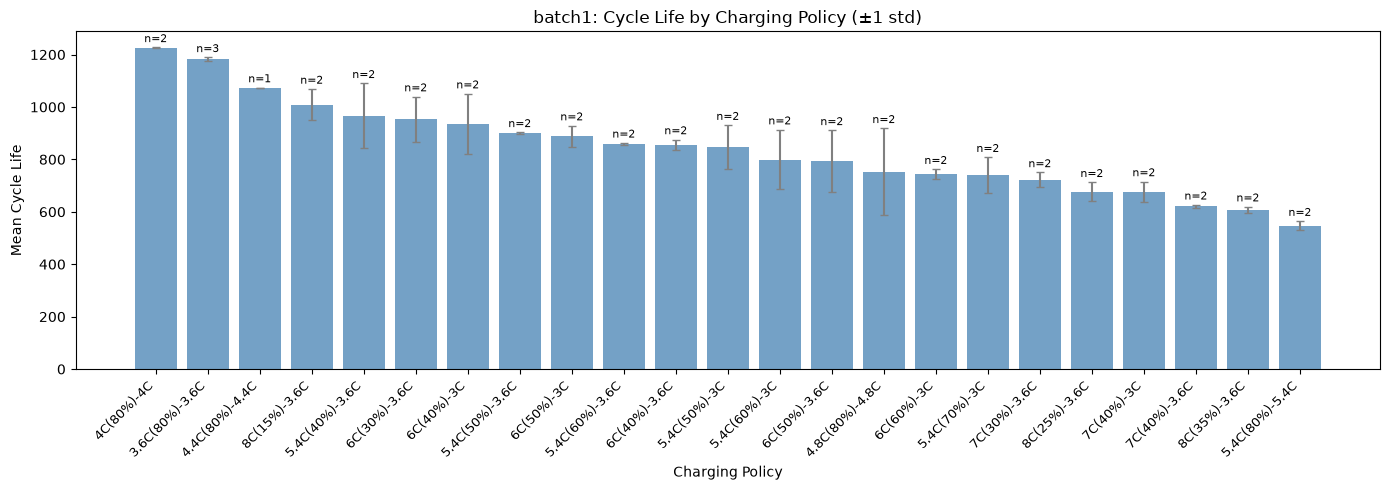

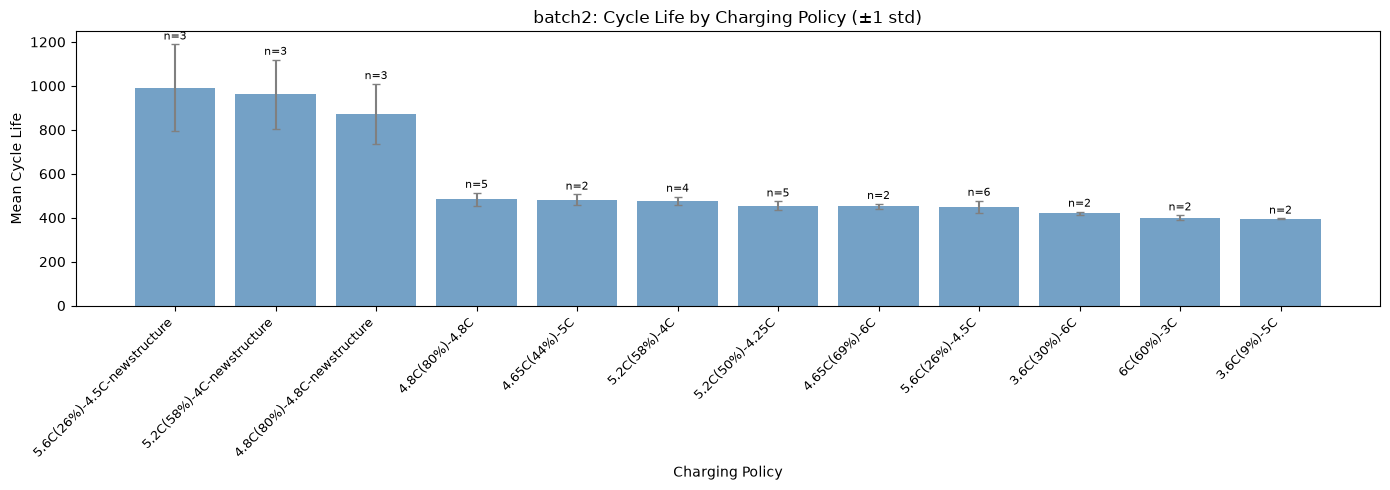

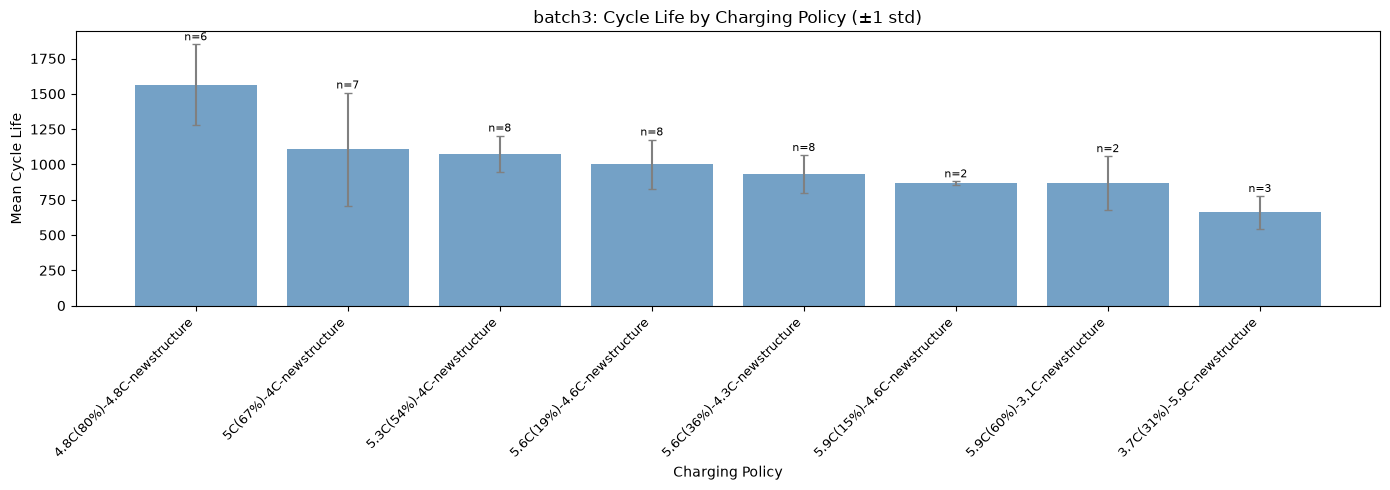

In [58]:
for name, data in df_cells.groupby("batch"):
    policy_life = (
        data.dropna(subset=["cycle_life"])
        .groupby("policy")["cycle_life"]
        .agg(["mean", "std", "count"])
        .sort_values("mean", ascending=False)
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(policy_life))

    bars = ax.bar(
        x,
        policy_life["mean"],
        # n=1이면 표준편차를 계산할 수 없어 오차 막대 생략
        yerr=policy_life["std"].fillna(0),
        color="steelblue",
        alpha=0.75,
        error_kw=dict(ecolor="gray", capsize=3),
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        policy_life.index,
        rotation=45,
        ha="right",
        fontsize=9,
    )
    ax.set_xlabel("Charging Policy")
    ax.set_ylabel("Mean Cycle Life")
    ax.set_title(f"{name}: Cycle Life by Charging Policy (±1 std)")

    for bar, (_, row) in zip(bars, policy_life.iterrows()):
        error = row["std"] if pd.notna(row["std"]) else 0

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + error + 10,
            f'n={int(row["count"])}',
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()

cells  known_life  mean_life  median_life
batch  policy                                                                
batch1 3.6C(80%)-3.6C                   3           3     1182.0       1179.0
       4.4C(80%)-4.4C                   1           1     1074.0       1074.0
       4.8C(80%)-4.8C                   2           2      753.0        753.0
       4C(80%)-4C                       2           2     1226.5       1226.5
       5.4C(40%)-3.6C                   2           2      966.5        966.5
       5.4C(50%)-3.6C                   2           2      899.5        899.5
       5.4C(50%)-3C                     2           2      847.0        847.0
       5.4C(60%)-3.6C                   2           2      859.5        859.5
       5.4C(60%)-3C                     2           2      799.5        799.5
       5.4C(70%)-3C                     2           2      739.5        739.5
       5.4C(80%)-5.4C                   2           2      546.5        546.5
       6C(30%)-3.6C                     2           2      952.5        952.5
       6C(40%)-3.6C                     2           2      856.0        856.0
       6C(40%)-3C                       2           2      935.5        935.5
       6C(50%)-3.6C                     2           2      792.5        792.5
       6C(50%)-3C                       2           2      888.5        888.5
       6C(60%)-3C                       2           2      744.0        744.0
       7C(30%)-3.6C                     2           2      722.5        722.5
       7C(40%)-3.6C                     2           2      621.0        621.0
       7C(40%)-3C                       2           2      676.0        676.0
       8C(15%)-3.6C                     2           2     1008.5       1008.5
       8C(25%)-3.6C                     2           2      676.5        676.5
       8C(35%)-3.6C                     2           2      607.5        607.5
batch2 3.6C(30%)-6C                     2           2      421.0        421.0
       3.6C(80%)-3.6C(SLOWCYCLE         1           0        NaN          NaN
       3.6C(9%)-5C                      2           2      394.5        394.5
       3.6C(9%)-5C(SLOWCYCLE            1           0        NaN          NaN
       4.65C(44%)-5C                    2           2      482.5        482.5
       4.65C(69%)-6C                    2           2      452.0        452.0
       4.8C(80%)-4.8C                   5           5      483.6        492.0
       4.8C(80%)-4.8C(SLOWCYCLE         1           0        NaN          NaN
       4.8C(80%)-4.8C-newstructure      3           3      871.7        809.0
       5.2C(50%)-4.25C                  5           5      454.0        449.0
       5.2C(58%)-4C                     4           4      477.8        483.0
       5.2C(58%)-4C(SLOWCYCLE           1           0        NaN          NaN
       5.2C(58%)-4C-newstructure        3           3      961.7        904.0
       5.6C(26%)-4.5C                   6           6      448.5        446.0
       5.6C(26%)-4.5C-newstructure      3           3      991.3        997.0
       6C(60%)-3C                       2           2      400.0        400.0
       VarCharge-2C-100cycles           1           0        NaN          NaN
       VarCharge-4C-100cycles           1           0        NaN          NaN
       VarCharge-6C-100cycles           1           0        NaN          NaN
       VarCharge-8C-100cycles           1           0        NaN          NaN
batch3 3.7C(31%)-5.9C-newstructure      3           3      660.0        667.0
       4.8C(80%)-4.8C-newstructure      8           6     1564.2       1640.0
       5.3C(54%)-4C-newstructure        8           8     1074.4       1051.0
       5.6C(19%)-4.6C-newstructure      8           8     1001.4       1038.0
       5.6C(36%)-4.3C-newstructure      8           8      930.9        890.5
       5.9C(15%)-4.6C-newstructure      2           2      867.0        867.0
       5.9C(60%)-3.1C-newstructure      2           2     

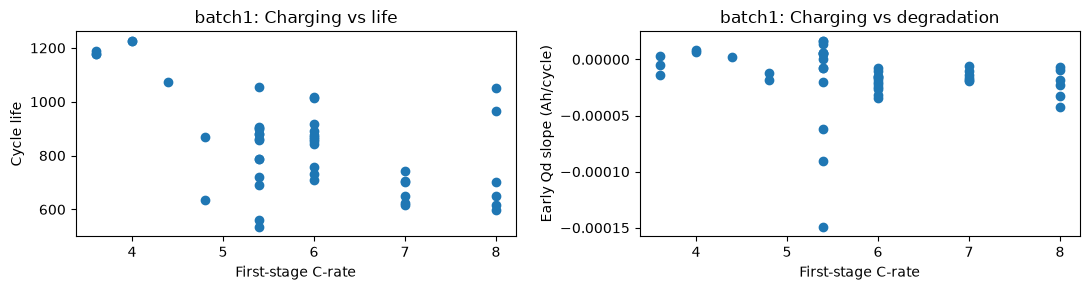


batch1: Spearman 상관계수


,C_rate,cycle_life,early_QD_slope,full_QD_slope
C_rate,1.000,-0.483,-0.439,-0.556
cycle_life,-0.483,1.000,0.578,0.934
early_QD_slope,-0.439,0.578,1.000,0.638
full_QD_slope,-0.556,0.934,0.638,1.000


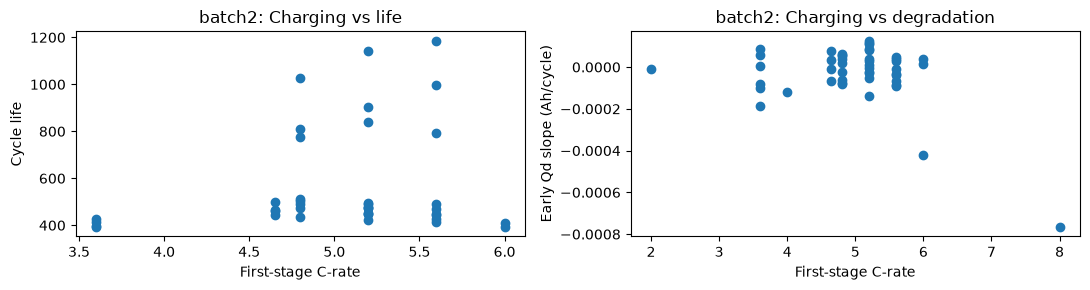


batch2: Spearman 상관계수


,C_rate,cycle_life,early_QD_slope,full_QD_slope
C_rate,1.000,0.055,-0.062,-0.129
cycle_life,0.055,1.000,-0.271,0.839
early_QD_slope,-0.062,-0.271,1.000,-0.175
full_QD_slope,-0.129,0.839,-0.175,1.000


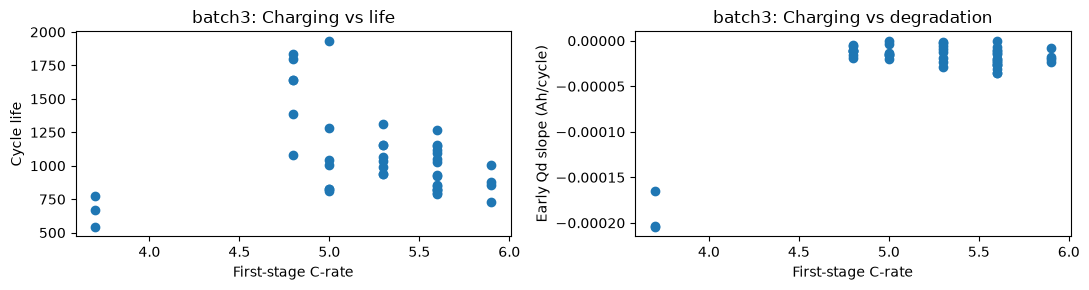


batch3: Spearman 상관계수


,C_rate,cycle_life,early_QD_slope,full_QD_slope
C_rate,1.000,-0.229,-0.127,-0.363
cycle_life,-0.229,1.000,0.184,0.909
early_QD_slope,-0.127,0.184,1.000,0.269
full_QD_slope,-0.363,0.909,0.269,1.000


In [57]:
# 충전 프로토콜별 평균 수명과 표본 수
policy_report = (
    df_cells.groupby(["batch", "policy"])
    .agg(
        cells=("cell_id", "size"),
        known_life=("cycle_life", "count"),
        mean_life=("cycle_life", "mean"),
        median_life=("cycle_life", "median"),
    )
)

display(policy_report.round(1))

for name, data in df_cells.groupby("batch"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3))

    axes[0].scatter(data["C_rate"], data["cycle_life"])
    axes[0].set(
        xlabel="First-stage C-rate",
        ylabel="Cycle life",
        title=f"{name}: Charging vs life",
    )

    axes[1].scatter(data["C_rate"], data["early_QD_slope"])
    axes[1].set(
        xlabel="First-stage C-rate",
        ylabel="Early Qd slope (Ah/cycle)",
        title=f"{name}: Charging vs degradation",
    )

    plt.tight_layout()
    plt.show()

    print(f"\n{name}: Spearman 상관계수")
    display(
        data[
            ["C_rate", "cycle_life", "early_QD_slope", "full_QD_slope"]
        ].corr(method="spearman").round(3)
    )

### 5) 초기 피처와 수명 및 Batch 비교


제외한 초기 빈 측정 행: 46개
상관 분석에서 제외한 수명 결측 셀: 10개


,cells,min_observed_cycles,max_observed_cycles
batch,,,
batch1,46,99,99
batch2,39,100,100
batch3,44,100,100


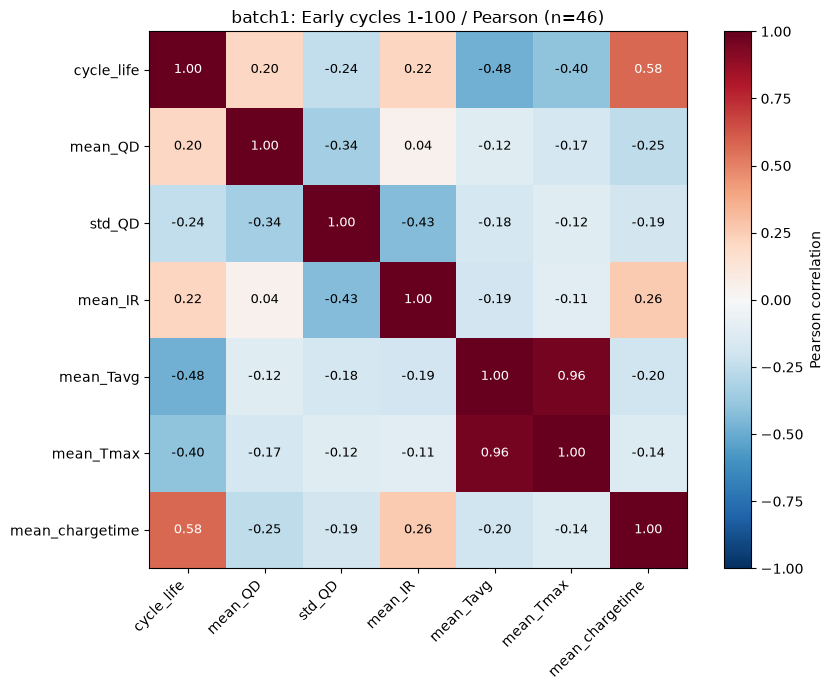


[batch1] Cycle life correlation rank


,pearson,n
mean_chargetime,0.577,46
mean_Tavg,-0.482,46
mean_Tmax,-0.404,46
std_QD,-0.243,46
mean_IR,0.218,46
mean_QD,0.205,46


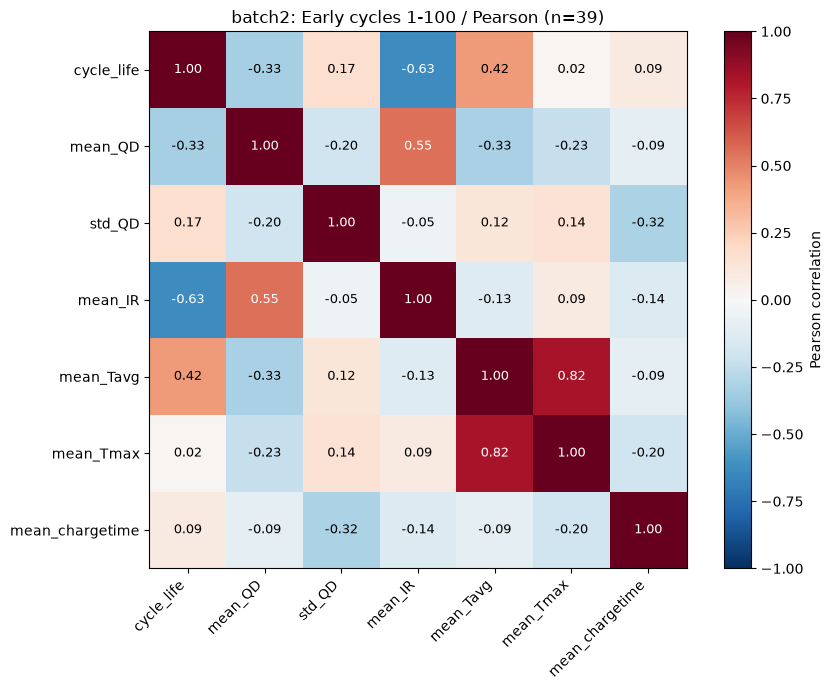


[batch2] Cycle life correlation rank


,pearson,n
mean_IR,-0.627,33
mean_Tavg,0.425,39
mean_QD,-0.332,39
std_QD,0.171,39
mean_chargetime,0.087,39
mean_Tmax,0.019,39


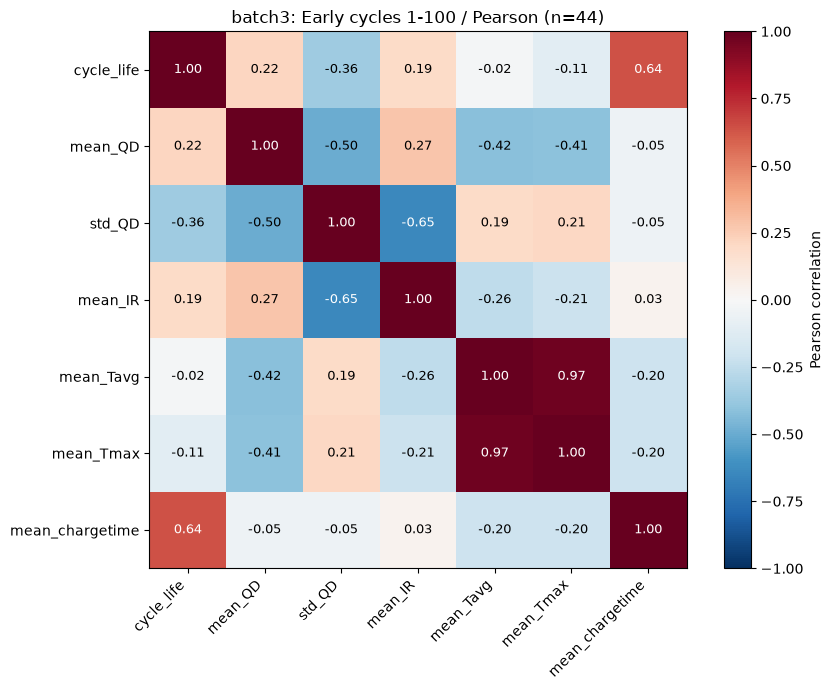


[batch3] Cycle life correlation rank


,pearson,n
mean_chargetime,0.637,44
std_QD,-0.356,44
mean_QD,0.217,44
mean_IR,0.190,44
mean_Tmax,-0.106,44
mean_Tavg,-0.022,44


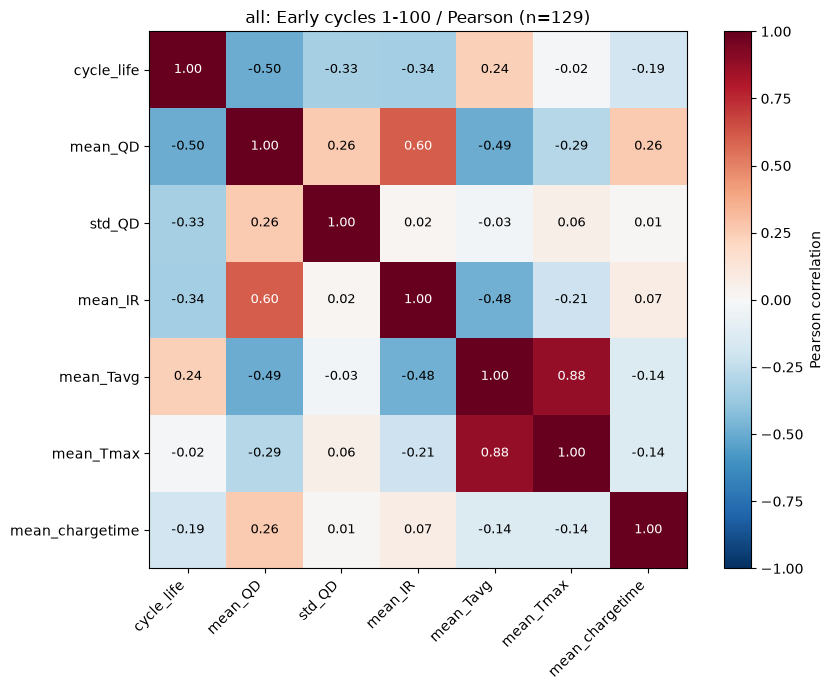


[all] Cycle life correlation rank


,pearson,n
mean_QD,-0.498,129
mean_IR,-0.336,123
std_QD,-0.328,129
mean_Tavg,0.238,129
mean_chargetime,-0.194,129
mean_Tmax,-0.017,129


In [ ]:
early_summary = df_summary.loc[df_summary["cycle"].between(1, 100)].copy()

# 용량·저항·온도·시간이 모두 0인 빈 측정 행은 제외
measurement_cols = ["QDischarge", "QCharge", "IR", "Tavg", "Tmax", "chargetime"]
empty_row = early_summary[measurement_cols].fillna(0).eq(0).all(axis=1)
print(f"제외한 초기 빈 측정 행: {empty_row.sum()}개")
early_summary = early_summary.loc[~empty_row].copy()
early_summary[measurement_cols] = early_summary[measurement_cols].replace([np.inf, -np.inf], np.nan)

for col in ["QDischarge", "QCharge"]:
    early_summary[col] = early_summary[col].where(
        early_summary[col].between(0, 1.43, inclusive="neither")
    )
for col in ["IR", "chargetime"]:
    early_summary[col] = early_summary[col].where(early_summary[col] > 0)

early_100 = early_summary.groupby(["batch", "cell_id"]).agg(
    observed_cycles=("cycle", "nunique"),
    mean_QD=("QDischarge", "mean"),
    std_QD=("QDischarge", "std"),
    mean_IR=("IR", "mean"),
    mean_Tavg=("Tavg", "mean"),
    mean_Tmax=("Tmax", "mean"),
    mean_chargetime=("chargetime", "mean"),
).reset_index()

early_100 = early_100.merge(
    df_cells[["cell_id", "cycle_life"]], on="cell_id", validate="one_to_one"
)
# 수명이 없는 셀은 수명과의 비교에서 제외
missing_life = early_100["cycle_life"].isna().sum()
print(f"상관 분석에서 제외한 수명 결측 셀: {missing_life}개")
early_100 = early_100.dropna(subset=["cycle_life"])

display(early_100.groupby("batch").agg(
    cells=("cell_id", "size"),
    min_observed_cycles=("observed_cycles", "min"),
    max_observed_cycles=("observed_cycles", "max"),
))

corr_columns = [
    "cycle_life", "mean_QD", "std_QD", "mean_IR",
    "mean_Tavg", "mean_Tmax", "mean_chargetime",
]


def plot_correlation(data, name):
    # 교수님 코드의 .corr()와 같은 Pearson 상관계수
    corr = data[corr_columns].corr(method="pearson", min_periods=4)
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax, label="Pearson correlation")
    ax.set_xticks(range(len(corr_columns)), corr_columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr_columns)), corr_columns)

    for i in range(len(corr_columns)):
        for j in range(len(corr_columns)):
            value = corr.iloc[i, j]
            label = f"{value:.2f}" if pd.notna(value) else "NA"
            color = "white" if pd.notna(value) and abs(value) > 0.5 else "black"
            ax.text(j, i, label, ha="center", va="center", color=color, fontsize=9)

    ax.set_title(f"{name}: Early cycles 1-100 / Pearson (n={len(data)})")
    plt.tight_layout()
    plt.show()

    rank = corr["cycle_life"].drop("cycle_life").sort_values(key=abs, ascending=False)
    valid_counts = data[corr_columns].notna().astype(int)
    pair_counts = valid_counts.T @ valid_counts
    print(f"\n[{name}] Cycle life correlation rank")
    display(pd.DataFrame({
        "pearson": rank,
        "n": pair_counts.loc[rank.index, "cycle_life"],
    }).round(3))
    return corr


correlation_matrices = {}
for name, data in early_100.groupby("batch"):
    correlation_matrices[name] = plot_correlation(data, name)
correlation_matrices["all"] = plot_correlation(early_100, "all")


#### 파생피쳐와 수명 및 Batch 비교

In [59]:
feature_columns = [
    "early_QD",
    "early_IR",
    "early_Tmax",
    "early_chargetime",
    "early_QD_slope",
    "delta_logvar",
    "delta_min",
]

# 동일한 초기 관측 기간을 가진 셀로 비교
early_cells = df_cells[df_cells["early_cycles"] == 91].copy()

correlation_rows = []

# Batch별 + 전체 데이터 상관관계
groups = list(early_cells.groupby("batch"))
groups.append(("all", early_cells))

for name, data in groups:
    print(f"\n{name}: 초기 구간이 있는 셀 {len(data)}개")

    for feature in feature_columns:
        pair = (
            data[[feature, "cycle_life"]]
            .replace([np.inf, -np.inf], np.nan).dropna()
        )

        correlation_rows.append({
            "batch": name,
            "feature": feature,
            "n": len(pair),
            "spearman": pair[feature].corr(
                pair["cycle_life"], method="spearman"
            ) if len(pair) >= 4 else np.nan,
        })

    # 다중공선성 후보: 피처끼리 강하게 연관되는 조합
    correlation = data[feature_columns].corr()

    for i, left in enumerate(feature_columns):
        for right in feature_columns[i + 1:]:
            value = correlation.loc[left, right]

            if pd.notna(value) and abs(value) >= 0.9:
                print(f"중복 피처 후보: {left} / {right}: {value:.2f}")

df_correlation = pd.DataFrame(correlation_rows)

display(
    df_correlation.pivot(
        index="feature", columns="batch", values="spearman"
    ).round(3)
)

# Batch마다 수명과 가장 강하게 연관된 피처
strongest = (
    df_correlation.dropna(subset=["spearman"])
    .assign(strength=lambda x: x["spearman"].abs())
    .sort_values("strength", ascending=False)
    .groupby("batch").head(1)
)

display(strongest[["batch", "feature", "n", "spearman"]])

# Batch 특성 종합 비교
comparison = df_cells.groupby("batch").agg(
    cells=("cell_id", "size"),
    known_life=("cycle_life", "count"),
    mean_life=("cycle_life", "mean"),
    median_life=("cycle_life", "median"),
    short_ratio=("cycle_life", lambda x: (x.dropna() < 500).mean()),
    long_ratio=("cycle_life", lambda x: (x.dropna() > 1000).mean()),
    policy_count=("policy", "nunique"),
    mean_C_rate=("C_rate", "mean"),
    mean_early_IR=("early_IR", "mean"),
    mean_early_Tmax=("early_Tmax", "mean"),
    median_early_slope=("early_QD_slope", "median"),
    median_delta_logvar=("delta_logvar", "median"),
)

comparison = comparison.join(
    df_knee.groupby("batch")["knee_cycle"]
    .agg(knee_candidates="count", median_knee="median")
)

display(comparison.round(4))


batch1: 초기 구간이 있는 셀 46개
중복 피처 후보: delta_logvar / delta_min: -0.95

batch2: 초기 구간이 있는 셀 47개
중복 피처 후보: delta_logvar / delta_min: -0.93

batch3: 초기 구간이 있는 셀 46개
중복 피처 후보: delta_logvar / delta_min: -0.93

all: 초기 구간이 있는 셀 139개
중복 피처 후보: delta_logvar / delta_min: -0.94


batch,all,batch1,batch2,batch3
feature,,,,
delta_logvar,-0.892,-0.871,-0.709,-0.797
delta_min,0.883,0.850,0.661,0.776
early_IR,-0.310,0.136,-0.343,0.167
early_QD,-0.505,0.241,0.095,0.163
early_QD_slope,-0.185,0.578,-0.271,0.184
early_Tmax,-0.011,-0.322,-0.126,-0.037
early_chargetime,-0.128,0.617,-0.391,0.202


,batch,feature,n,spearman
26,all,delta_logvar,129,-0.892074
5,batch1,delta_logvar,46,-0.871161
19,batch3,delta_logvar,44,-0.797237
12,batch2,delta_logvar,39,-0.708979


,cells,known_life,mean_life,median_life,short_ratio,long_ratio,policy_count,mean_C_rate,mean_early_IR,mean_early_Tmax,median_early_slope,median_delta_logvar,knee_candidates,median_knee
batch,,,,,,,,,,,,,,
batch1,46,46,844.7174,858.5,0.0000,0.2174,23,5.8783,0.0165,35.8857,-0.0,-3.8512,46,600.5
batch2,47,39,565.7436,472.0,0.7179,0.0769,20,4.9660,0.0144,44.1975,-0.0,-3.4949,44,351.0
batch3,46,44,1059.6591,1005.5,0.0000,0.5227,8,5.2196,0.0153,36.9335,-0.0,-4.1990,46,799.0
